In [40]:
# Import required libraries
from pathlib import Path

from tree_detection_framework.preprocessing.preprocessing import (
    create_dataloader,
    create_intersection_dataloader,
)
from tree_detection_framework.detection.detector import (
    GeometricTreeTopDetector,
    GeometricTreeCrownDetector,
)
from tree_detection_framework.constants import DATA_FOLDER
from tree_detection_framework.postprocessing.postprocessing import (
    remove_edge_detections,
    multi_region_NMS,
    single_region_hole_suppression,
)
from tree_detection_framework.preprocessing.preprocessing import visualize_dataloader

In [41]:
# The path to a Canopy Height Model raster file
RASTER_FOLDER_PATH = Path(DATA_FOLDER, "emerald-point-chm")
RASTER_FILE_PATH = Path(RASTER_FOLDER_PATH, "chm.tif")
# Prediction file path
OUTPUT_TREETOPS_FILE_PATH = Path(
    RASTER_FOLDER_PATH, "emerald-point-chm-geometric-tree-tops.gpkg"
)
OUTPUT_TREECROWNS_FILE_PATH = Path(
    RASTER_FOLDER_PATH, "emerald-point-chm-geometric-tree-crowns.gpkg"
)
# The size of the chips in pixels
CHIP_SIZE = 512
# The stride between chips in pixels
CHIP_STRIDE = 400
# The spatial resolution that the data is sampled to in meters/pix
RESOLUTION = 0.2
# The blur resolution
BLUR_SIGMA_METERS = 0.5
# The number of tiles to show from the dataloader
N_VIS_TILES = 3

In [42]:
# Stage 1: Create a dataloader for the raster data and detect the tree-tops
dataloader = create_dataloader(
    raster_folder_path=RASTER_FOLDER_PATH,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
)

INFO:root:Units = Units.PIXELS
INFO:root:Stride = 400


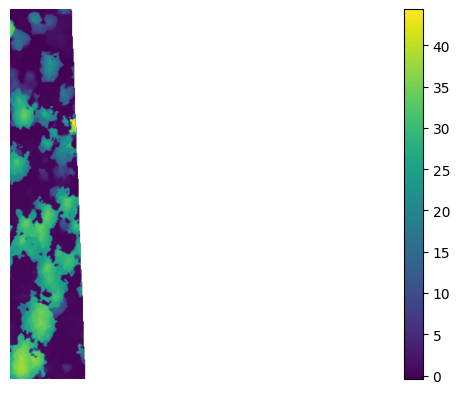

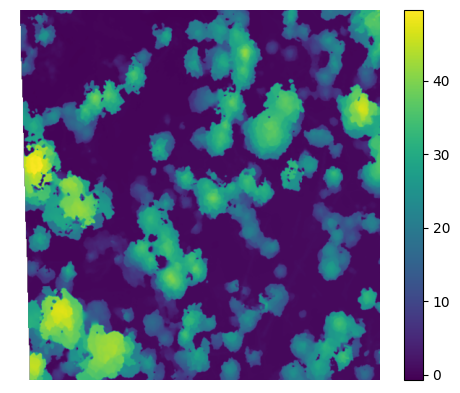

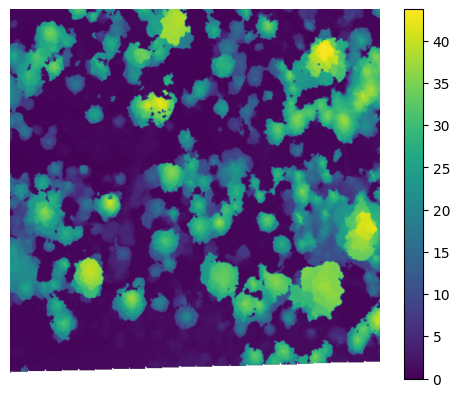

In [43]:
visualize_dataloader(dataloader, n_tiles=N_VIS_TILES)

In [44]:
treetop_detector = GeometricTreeTopDetector(
    a=0, b=0.0325, c=0.25, blur_sigma=BLUR_SIGMA_METERS, confidence_feature="height"
)

treetop_detections = treetop_detector.predict(dataloader)

Performing prediction on batches: 100%|██████████| 16/16 [00:07<00:00,  2.10it/s]


In [45]:
# Remove the tree tops that were generated in the edges of tiles. This is an alternative to NMS.
treetop_detections = remove_edge_detections(
    treetop_detections,
    suppression_distance=(CHIP_SIZE - CHIP_STRIDE) * RESOLUTION / 2,
)

In [46]:
# Save the treetops to disk
treetop_detections.save(OUTPUT_TREETOPS_FILE_PATH)

INFO:pyogrio._io:Created 1,155 records


In [47]:
# Stage 2: Combine raster and vector data (from the tree-top detector) to create a new dataloader
raster_vector_dataloader = create_intersection_dataloader(
    raster_data=RASTER_FOLDER_PATH,
    vector_data=treetop_detections,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
)

treecrown_detector = GeometricTreeCrownDetector(approach="watershed")

treecrown_detections = treecrown_detector.predict(raster_vector_dataloader)

INFO:root:Stride = 400
INFO:root:Units = Units.PIXELS
INFO:pyogrio._io:Created 1,155 records
INFO:root:RegionDetectionsSet temporarily saved to: /tmp/tmp4ps8a3jq.geojson


Converting CustomRasterDataset CRS from EPSG:26910 to EPSG:26910


INFO:root:Using watershed approach to compute the tree crowns.
Performing prediction on batches: 100%|██████████| 12/12 [00:02<00:00,  4.71it/s]


In [48]:
# Suppress overlapping crown predictions. This step can be slow.
treecrown_detections = multi_region_NMS(
    treecrown_detections, confidence_column="score", intersection_method="IOS"
)

INFO:root:Bound have overlap, running across-region NMS


In [49]:
# Display outputs from the tree crown detector. Note: treetop UIDs get maintained.
treecrown_detections.get_data_frame()

,score,height,treetop_unique_ID,geometry,region_ID,unique_ID
6,778.0,37.372292,00409,"POLYGON ((752273.49 4317073.499, 752271.89 431...",0,00006
7,654.5,30.261284,00410,"POLYGON ((752238.09 4317072.299, 752236.89 431...",0,00007
11,715.5,20.303604,00415,"POLYGON ((752293.29 4317065.899, 752292.09 431...",0,00011
12,2464.5,39.904297,00412,"POLYGON ((752264.29 4317073.499, 752264.89 431...",0,00012
13,408.0,25.439993,00530,"POLYGON ((752328.09 4317065.299, 752327.29 431...",0,00013
...,...,...,...,...,...,...
1665,542.0,19.476185,01138,"POLYGON ((752467.49 4317220.899, 752466.29 431...",11,01665
1666,474.0,20.925230,01142,"POLYGON ((752435.89 4317219.099, 752434.29 431...",11,01666
1668,1519.0,34.995121,01141,"POLYGON ((752438.69 4317221.499, 752438.09 431...",11,01668
1669,512.5,13.140085,01145,"POLYGON ((752449.89 4317217.499, 752448.29 431...",11,01669


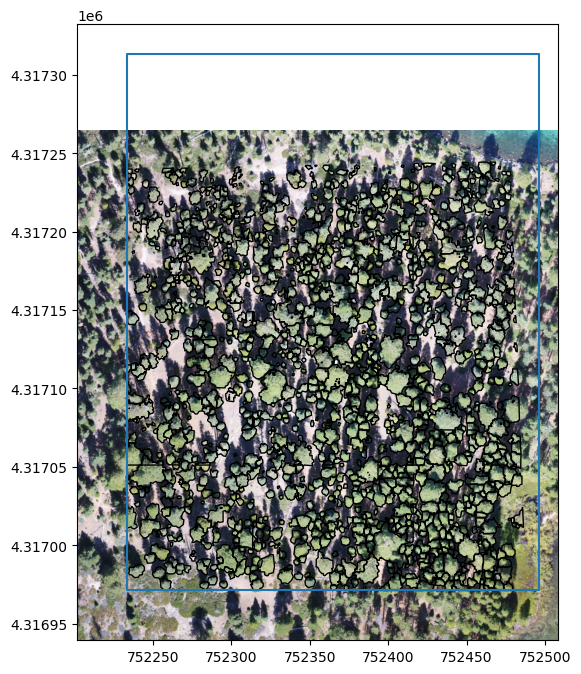

<Axes: >

In [50]:
treecrown_detections.plot(
    raster_file=Path(DATA_FOLDER, "emerald-point-ortho/ortho.tif")
)

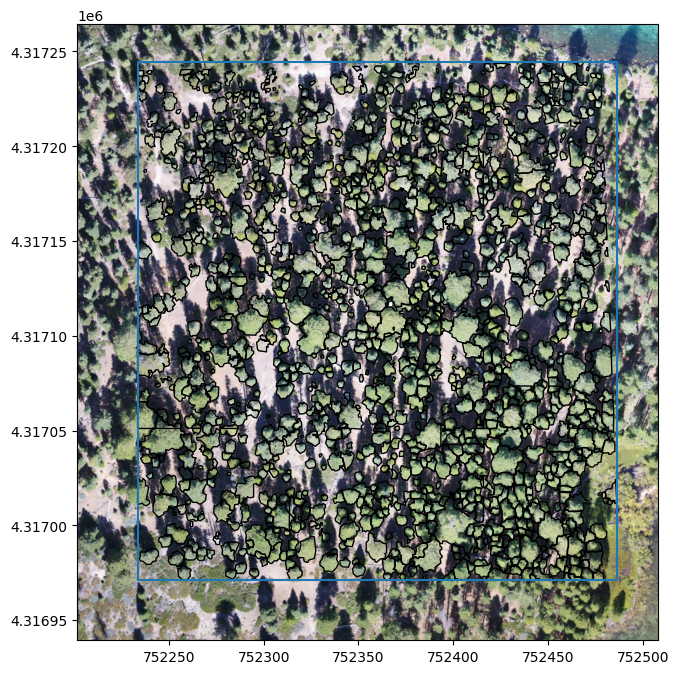

<Axes: >

In [51]:
# Post-processing step to remove holes in the tree crowns
treecrown_detections = single_region_hole_suppression(treecrown_detections)
treecrown_detections.plot(
    raster_file=Path(DATA_FOLDER, "emerald-point-ortho/ortho.tif")
)

In [52]:
treecrown_detections.save(OUTPUT_TREECROWNS_FILE_PATH)

INFO:pyogrio._io:Created 1,149 records
